# Загрузка файлов

В лабораторной работе предстоит работать с двумя файлами:
- ai_job.csv
- ai_index.csv

В файле о будущем работы в эпоху ИИ в лабораторной работе используются следующие показатели:
- industry
- country
- year
- automation_risk_percent
- salary_after_usd
- salary_change_percent

В файле об индексе готовности к внедрению ИИ:
- country
- year
- ai_index_score
- ai_investment_billion_usd
- government_ai_spending
- ai_research_papers
- ai_startups_count (только в улучшении на 9-10)

Именно эти показатели **нужно проверить и очистить** до построения графиков. Остальные столбцы можно не трогать – они не влияют на анализ.

Разбалловка:
- Очистка данных - 2 балла
- Графики в заданиях 2-7 - по 1 баллу каждый

К каждому графику есть вариант с улучшением - для повышения балла до 10 нужно либо реализовать 2 любых улучшения к графикам из зданий 2-6, либо 1 улучшение к последнему графику с subplots

## Задание 1. Очистка данных (2 балла)

Выполните шаги только для перечисленных ниже столбцов. Остальные столбцы оставьте как есть.

1. Приведение к числовому типу. В датафрейме `df_index` столбец `ai_research_papers` содержит строки 'Unknown'. Примените `pd.to_numeric(..., errors='coerce')` к этому столбцу.

2. Обработка выбросов. Найдите выбросы методом IQR (межквартильный размах) с коэффициентом 1.5 и замените их на `np.nan`.
      
    - В `df_index` в столбце `government_ai_spending`

3. Заполнение пропусков

    1. Линейная интерполяция (по годам, внутри каждой страны). Для интерполяции обязательно отсортируйте данные по `country` и `year` и используйте `groupby('country')` с методом `interpolate(method='linear', limit_direction='both')`.

        - `df_job`: столбец `salary_change_percent`
        - `df_index`: столбец `ai_investment_billion_usd`

    2. Медиана по стране (для остальных целевых столбцов). Используйте `groupby('country')` и `transform(lambda x: x.fillna(x.median()))`.

        - `df_job`: столбцы `salary_change_percent`, `automation_risk_percent`, `salary_after_usd`
        - `df_index`: столбцы `ai_index_score`, `government_ai_spending`, `ai_research_papers`

4. Соединение датафреймов
После очистки объедините  `df_job` и `df_index` по столбцам `['country', 'year']` с типом `inner`. Результат сохраните в `df_merged`.

***Подсказка***: действия по очистке удобно собрать в отдельные функции


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_job = pd.read_csv(r"D:\Repos\Data_analysis_with_Python\ai_job.csv")
data_index = pd.read_csv(r"D:\Repos\Data_analysis_with_Python\ai_index.csv")

data_index["ai_research_papers"] = pd.to_numeric(data_index["ai_research_papers"], errors='coerce')

In [127]:
# YOUR CODE HERE
def find_outliers(data):    
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    mask1 = ((q1 - 1.5 * iqr) > data) 
    mask2 = data > q3 + 1.5 * iqr
    return (mask1 | mask2)

outliers_mask = find_outliers(data_index["government_ai_spending"])
data_index.loc[outliers_mask, "government_ai_spending"] = np.nan

In [148]:
# YOUR CODE HERE
data_job = data_job.sort_values(["country", "year"])
countries = data_job['country'].unique()
for country in countries:
    mask = data_job['country'] == country
    data_job.loc[mask, 'salary_change_percent'] = data_job.loc[mask, 'salary_change_percent'].interpolate(method='linear', limit_direction='both')
    
data_index = data_index.sort_values(['country', 'year'])
countries = data_index['country'].unique()
for country in countries:
    mask = data_index['country'] == country    
    data_index.loc[mask, 'ai_investment_billion_usd'] = data_index.loc[mask, 'ai_investment_billion_usd'].interpolate(method='linear', limit_direction='both')



columns_job = ['salary_change_percent', 'automation_risk_percent', 'salary_after_usd']
for col in columns_job:
    data_job[col] = data_job.groupby('country')[col].transform(lambda x: x.fillna(x.median()))

columns_index = ['ai_index_score', 'government_ai_spending', 'ai_research_papers']
for col in columns_index:
    data_index[col] = data_index.groupby('country')[col].transform(lambda x: x.fillna(x.median()))


df_merged = pd.merge(data_index,data_job,how="inner",on=["country", "year"])

## Задание 2. Линейный график (1 балл)

**Датафрейм: `df_merged` (объединенный)**

- Для каждой страны, используя groupby, вычислите средний `automation_risk_percent` (из объединённого фрейма).

- Найдите 3 страны (используйте сортировку к полученной таблице с группировкой):

    - с максимальным риском,
    - с медианным риском,
    - с минимальным риском.

- Для этих трёх стран постройте линейный график изменения `ai_index_score` по годам.

- Добавьте заголовок, подписи осей, легенду с названиями стран и указанием риска.


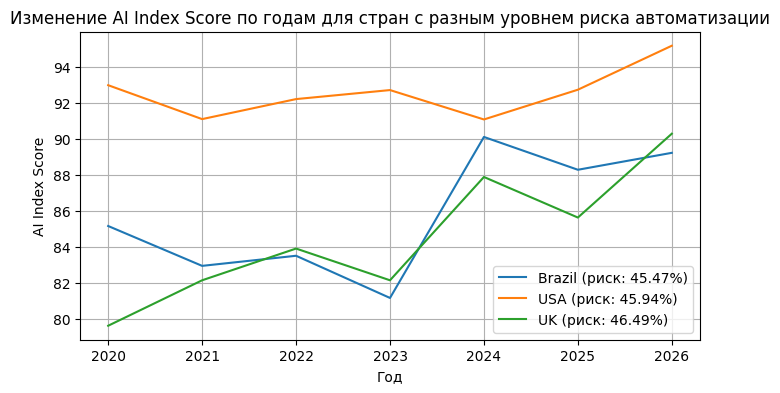

In [144]:
# YOUR CODE HERE
country_risk = df_merged.groupby('country')['automation_risk_percent'].mean().reset_index()
country_risk.columns = ['country', 'mean_risk']

country_risk_sorted = country_risk.sort_values('mean_risk')
min_country = country_risk_sorted.iloc[0]['country']            
max_country = country_risk_sorted.iloc[-1]['country']                

median_risk = country_risk_sorted['mean_risk'].median()
median_country = country_risk_sorted.iloc[
    (country_risk_sorted['mean_risk'] - median_risk).abs().argsort()[:1]
].iloc[0]['country']
filtered = df_merged[df_merged['country'].isin([min_country, median_country, max_country])]

plt.figure(figsize=(8, 4))
for country in [min_country, median_country, max_country]:
    data = filtered[filtered['country'] == country].sort_values('year')
    risk_value = country_risk[country_risk['country'] == country]['mean_risk'].values[0]
    plt.plot(data['year'], data['ai_index_score'], 
             label=f'{country} (риск: {risk_value:.2f}%)')

plt.title('Изменение AI Index Score по годам для стран с разным уровнем риска автоматизации')
plt.xlabel('Год')
plt.ylabel('AI Index Score')
plt.legend()
plt.grid(True)
plt.show()

### Улучшение

- Глобальное среднее – для каждого года вычислите среднее `ai_index_score` по всем странам.
    - Отобразите его на том же графике пунктирной линией
    - Подпишите эту линию в легенде.

- Публикационное оформление:
    - Увеличьте размер фигуры (например, figsize=(10,6)).
    - Сделайте подписи осей и заголовок более крупными.
    - Включите сетку с полупрозрачными линиями.
    - Добавьте маркеры на точках для каждой страны.

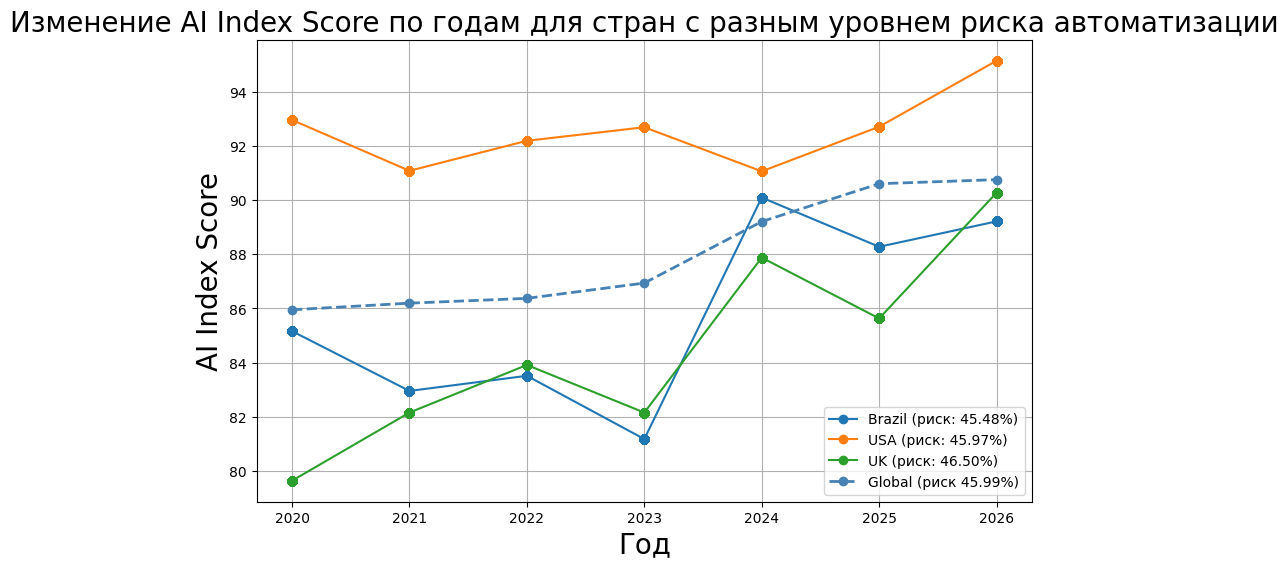

In [130]:
# YOUR CODE HERE
mean_all_country = df_merged.groupby(["year"])["ai_index_score"].mean().reset_index()
mean_all_country.columns = ["year", "mean"]

plt.figure(figsize=(10, 6))
for country in [min_country, median_country, max_country]:

    data = filtered[filtered['country'] == country].sort_values('year')

    risk_value = country_risk[country_risk['country'] == country]['mean_risk'].mean()
    plt.plot(data['year'], data['ai_index_score'], marker='o', 
             label=f'{country} (риск: {risk_value:.2f}%)')

plt.plot(mean_all_country["year"], mean_all_country["mean"], color='steelblue', lw=2,
         linestyle='--', label=f'Global (риск {country_risk["mean_risk"].mean():.2f}%)', marker='o')
plt.title('Изменение AI Index Score по годам для стран с разным уровнем риска автоматизации',fontsize ="20")
plt.xlabel('Год',fontsize ="20")
plt.ylabel('AI Index Score',fontsize ="20")
plt.legend()
plt.grid(True)
plt.show()

## Задание 3. Бар-чарт (1 балл)

**Датафрейм: `df_index (исходный)`**

- Отфильтруйте данные за 2026 год.
- Выберите топ‑5 стран по `ai_investment_billion_usd`.
- Постройте столбчатую диаграмму с накоплением (stacked), где каждый столбец делится на:
    - `government_ai_spending`
    - `ai_investment_billion_usd` - `government_ai_spending` (частные инвестиции)

- Подпишите оси, добавьте заголовок, легенду.

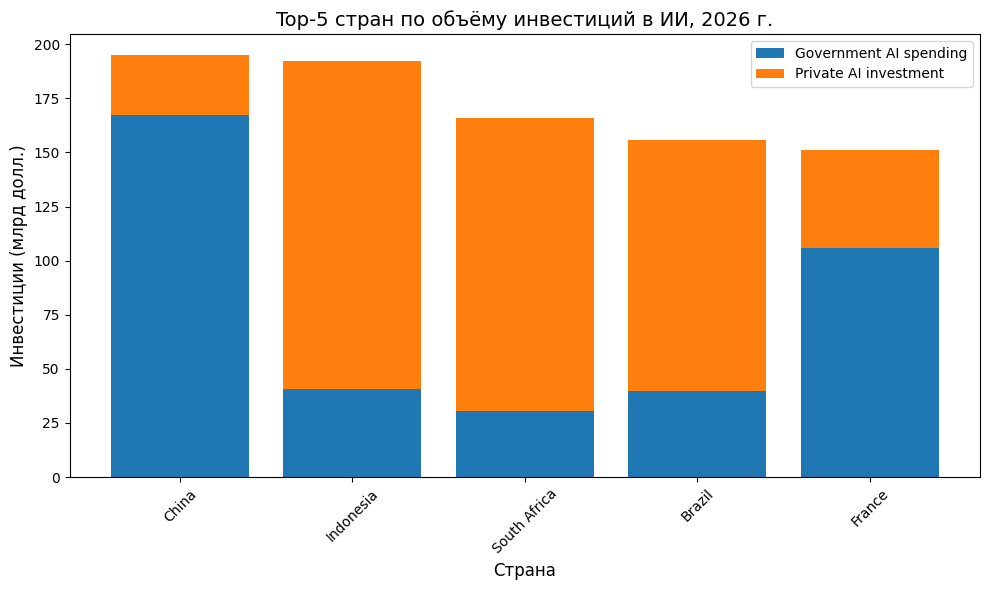

In [131]:
# YOUR CODE HERE
data_2026 = data_index[data_index['year'] == 2026].copy()

top5 = data_2026.nlargest(5, 'ai_investment_billion_usd')
top5['private_investment'] = top5['ai_investment_billion_usd'] - top5['government_ai_spending']
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(top5['country'], top5['government_ai_spending'], label='Government AI spending')
ax1.bar(top5['country'], top5['private_investment'], bottom=top5['government_ai_spending'], label='Private AI investment')
ax1.set_title('Top-5 стран по объёму инвестиций в ИИ, 2026 г.', fontsize=14)
ax1.set_xlabel('Страна', fontsize=12)
ax1.set_ylabel('Инвестиции (млрд долл.)', fontsize=12)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()


### Улучшение

- Вторая ось (twinx) со стартапами – создайте правую ось. На ее основе добавьте горизонтальную пунктирную линию глобального среднего значения ai_startups_count (вычисленного по всем странам за 2026 год).
- Подписи процентов внутри столбцов – для каждого сегмента (государственные и частные инвестиции) добавьте текстовую подпись с долей в процентах (центрированную внутри сегмента).
- Публикационное оформление:
    - Увеличьте размер фигуры (figsize=(12,6)).
    - Сделайте подписи осей и заголовок более крупными.
    - Легенды для обеих осей разместите аккуратно (например, первая легенда – вверху слева, вторая – вверху справа).
    - Добавьте сетку по основной оси Y.

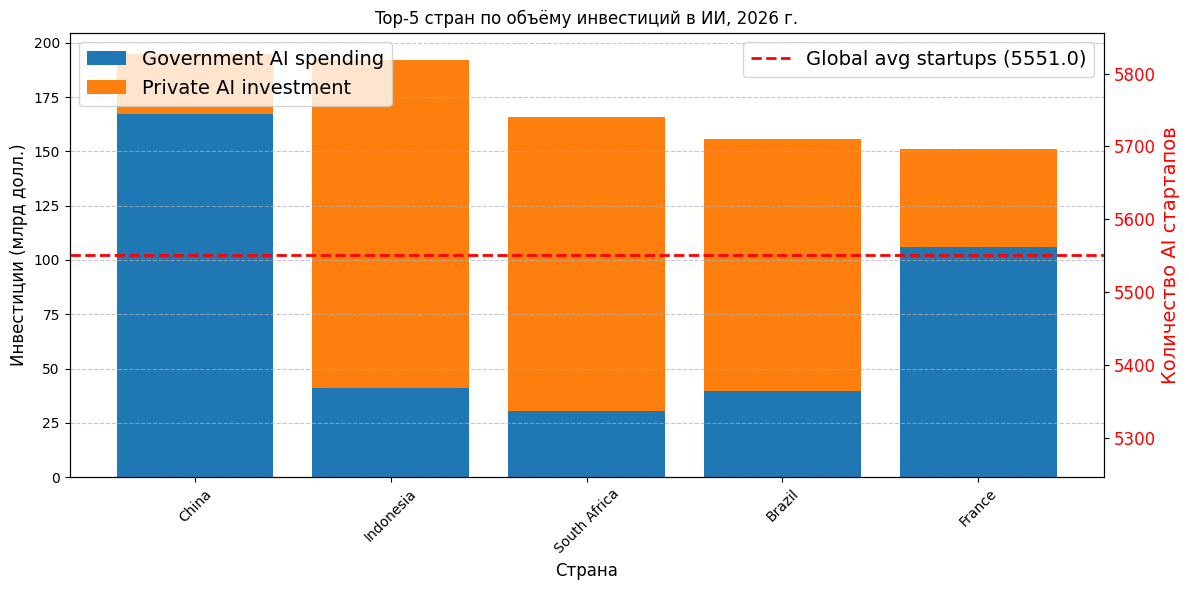

In [132]:
# YOUR CODE HERE

data_2026 = data_index[data_index['year'] == 2026].copy()

top5 = data_2026.nlargest(5, 'ai_investment_billion_usd')
top5['private_investment'] = top5['ai_investment_billion_usd'] - top5['government_ai_spending']
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(top5['country'], top5['government_ai_spending'], label='Government AI spending')
ax1.bar(top5['country'], top5['private_investment'], bottom=top5['government_ai_spending'], label='Private AI investment')
ax1.set_title('Top-5 стран по объёму инвестиций в ИИ, 2026 г.')
ax1.set_xlabel('Страна', fontsize=12)
ax1.set_ylabel('Инвестиции (млрд долл.)', fontsize=12)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7) 
ax1.legend()
ax1.tick_params(axis='x', rotation=45)


ax2 = ax1.twinx()
global_avg_startups = data_2026["ai_startups_count"].mean()
ax2.axhline(y=global_avg_startups, color='red', linestyle='--', linewidth=2, 
            label=f'Global avg startups ({global_avg_startups:.1f})')
ax2.set_ylabel('Количество AI стартапов', fontsize=14, color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=12)
ax1.legend(loc='upper left', fontsize=14)
ax2.legend(loc='upper right', fontsize=14)
fig.tight_layout()
plt.show()

## Задание 4. Пай-чарт (1 балл)

**Датафрейм: `df_index (исходный)`**

- Отфильтруйте данные за 2026 год.
- сгруппируйте по `country`, просуммируйте `ai_research_papers`
- возьмите топ‑5 стран, остальные объедините в категорию "Others"
- Постройте круговую диаграмму.

Добавьте подписи секторов и проценты.



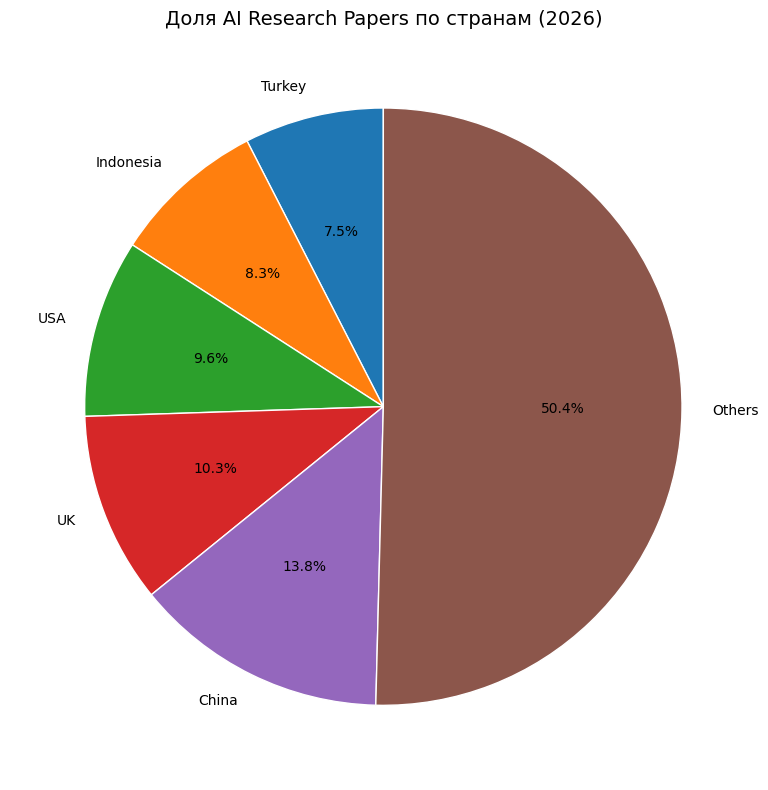

In [133]:
# YOUR CODE HERE
data_2026 = data_index[data_index['year'] == 2026].copy()
ai_researches = data_2026.groupby("country")["ai_research_papers"].sum().reset_index()
ai_researches_sorted = ai_researches.sort_values("ai_research_papers")

top_five = ai_researches_sorted.iloc[-5:]
others_sum = ai_researches_sorted.iloc[:-5]["ai_research_papers"].sum()
others_row = pd.DataFrame([{'country': 'Others', 'ai_research_papers': others_sum}])
plot_data = pd.concat([top_five, others_row], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(plot_data['ai_research_papers'], 
        labels=plot_data['country'], 
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Доля AI Research Papers по странам (2026)', fontsize=14)
plt.tight_layout()
plt.show()


### Улучшение

- Используйте любую приемлемую цветовую палитру, чтобы секторы легко различались (можно задать цвета явно или использовать готовую палитру). При этом страну-лидера можно выделить ярким акцентным цветом, а "Others" сделать нейтральным (серым).

- Публикационное оформление:
    - Увеличьте размер фигуры (например, figsize=(10, 8)).
    - Сделайте текст процентов жирным.
    - Увеличьте размер заголовка и подписей к секторам.

In [134]:
# YOUR CODE HERE

## Задание 5. Гистограмма (1 балл)

**Датафрейм: `df_index (исходный)`**

- Извлеките `ai_index_score` для 2016 и 2026 годов (два отдельных массива).
- Постройте две гистограммы на одном графике (прозрачные, перекрывающиеся).
- В качестве bins используйте массив из 20 чисел, равномерно распределенных в интервале от 0 до 100 включительно (`np.linspace`)

- Добавьте заголовок, подписи осей, легенду.



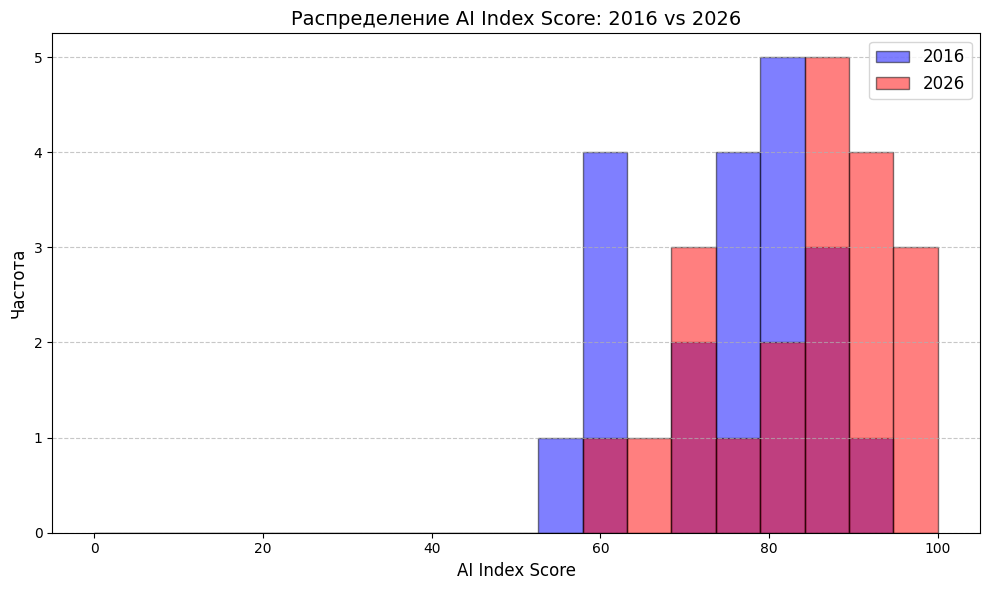

In [135]:
# YOUR CODE HERE
ai_index_score_2016 = data_index[data_index['year'] == 2016]["ai_index_score"]

ai_index_score_2026 = data_index[data_index['year'] == 2026]["ai_index_score"]

bins = np.linspace(0, 100, 20)  

plt.figure(figsize=(10, 6))
plt.hist(ai_index_score_2016, bins=bins, alpha=0.5, label='2016', color='blue', edgecolor='black')
plt.hist(ai_index_score_2026, bins=bins, alpha=0.5, label='2026', color='red', edgecolor='black')


plt.title('Распределение AI Index Score: 2016 vs 2026', fontsize=14)
plt.xlabel('AI Index Score', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Улучшение

- Для каждого года (2016 и 2026) добавьте линии:
    - Среднее (mean) – одного цвета,
    - Медиану (median) – другого цвета.
    - Подберите для них цвет в соответствии с годом, но разные варианты пунтира (например, 2016 год - синий, 2026 - красный, для среднего `linestyle='--'`, для медианы - `':'`)
    - Линии должны быть подписаны в легенде.

- Публикационное оформление:
    - Увеличьте размер фигуры (`figsize=(10,6)`).
    - Сделайте заголовок и подписи осей крупнее.
    - Добавьте сетку по оси Y.
    - Для лучшей читаемости используйте плотность (`density=True`), чтобы сравнивать распределения разного объёма.
    - Легенду разместите в верхнем левом углу.

In [136]:
# YOUR CODE HERE

## Задание 6. Бокс-плоты (1 балл)

**Датафрейм: `df_job (исходный)`**


- Отфильтруйте данные за 2026 год.
- Постройте boxplot распределения `salary_change_percent` по отраслям. Для этого:
    - соберите данные в список списков значений `salary_change_percent` по отраслям
- Добавьте заголовок, подписи осей.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19564\2534153151.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=industries, patch_artist=True)


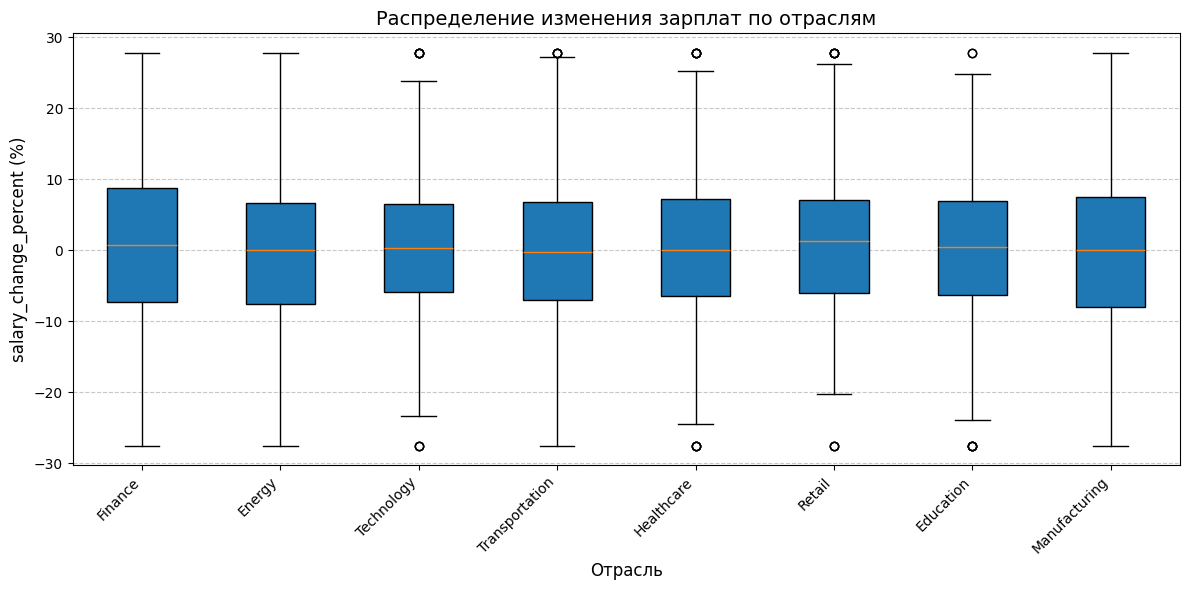

In [147]:
# YOUR CODE HERE
data_2026 = data_job[data_job['year'] == 2026].copy()
invest = data_2026['salary_change_percent'].dropna()

Q1 = invest.quantile(0.25)
Q3 = invest.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data_2026['salary_change_percent'] = data_2026['salary_change_percent'].clip(lower=lower, upper=upper)

industries = data_2026['industry'].unique()

data_to_plot = [data_2026[data_2026['industry'] == ind]['salary_change_percent'].dropna().values 
                for ind in industries]

plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=industries, patch_artist=True)
plt.title('Распределение изменения зарплат по отраслям', fontsize=14)
plt.xlabel('Отрасль', fontsize=12)
plt.ylabel('salary_change_percent (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Улучшение

- Текстовый блок:

    - Вычислите среднюю и медианную зарплату (`salary_after_usd`) по всем отраслям за 2026 год.
    - Разместите текстовый блок `plt.annotate` с этой информацией сверху, по центру или любому краю графика. Будьте аккуратны с текстом - он должен быть кратким и не перекрывать график.

- Публикационное оформление:
    - Размер фигуры (10,6).
    - Закрасьте ящики (например, светло-голубым).
    - Увеличьте размер шрифтов заголовка и подписей.

In [138]:
# YOUR CODE HERE

## Задание 7. Subplots (1 балл)

- Объединить 3-4 графика в один общий графический интерфейс (=дашборд). В качестве графиков взять несколько наиболее информативных из предыдущих заданий.
- Использовать `plt.subplots()` для размещения графиков.
- Добавить общий заголовок для всего дашборда.
- Сделать внешний вид аккуратным и читаемым.

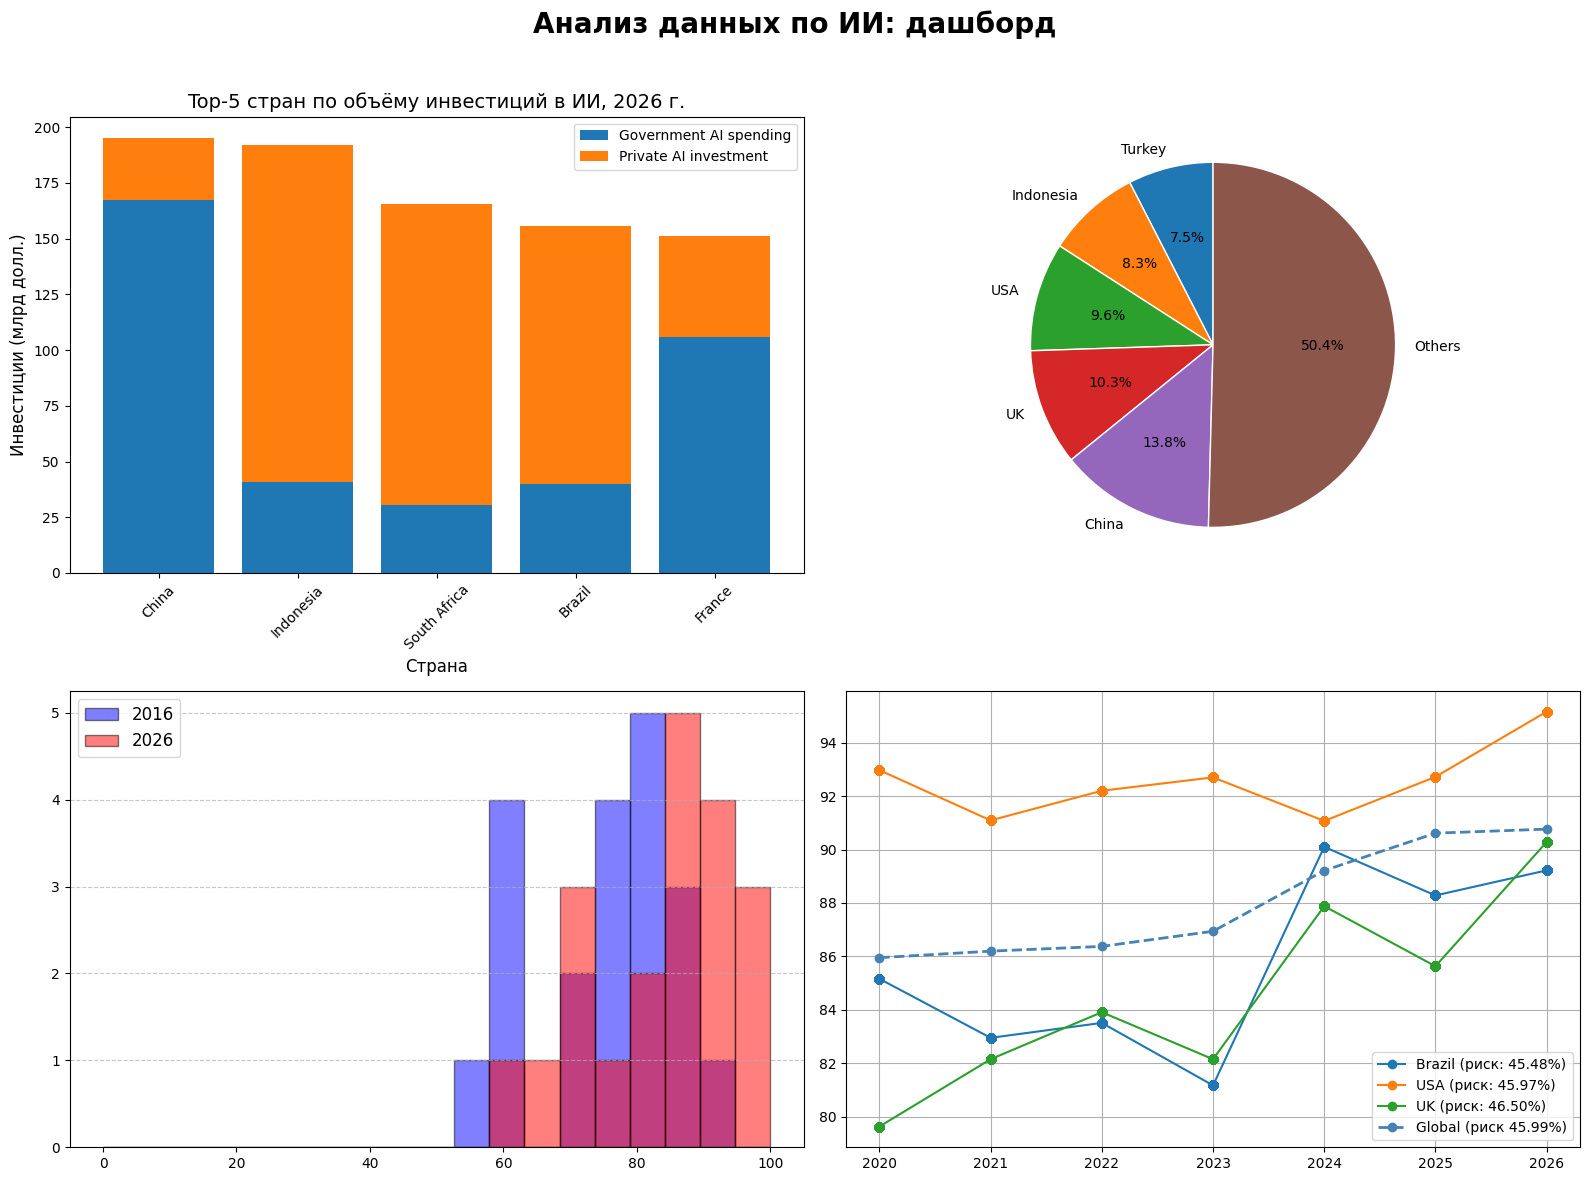

In [139]:
# YOUR CODE HERE

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ данных по ИИ: дашборд', fontsize=20, fontweight='bold')

# ---------- График 1: Линейный график AI Index Score для трёх стран ----------
# (используем данные из Задания 2)
ax1 = axes[0, 0]
ax1.bar(top5['country'], top5['government_ai_spending'], label='Government AI spending')
ax1.bar(top5['country'], top5['private_investment'], bottom=top5['government_ai_spending'], label='Private AI investment')
ax1.set_title('Top-5 стран по объёму инвестиций в ИИ, 2026 г.', fontsize=14)
ax1.set_xlabel('Страна', fontsize=12)
ax1.set_ylabel('Инвестиции (млрд долл.)', fontsize=12)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[0, 1]
ax2.pie(plot_data['ai_research_papers'], 
        labels=plot_data['country'], 
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})

ax3 = axes[1, 0]
ax3.hist(ai_index_score_2016, bins=bins, alpha=0.5, label='2016', color='blue', edgecolor='black')
ax3.hist(ai_index_score_2026, bins=bins, alpha=0.5, label='2026', color='red', edgecolor='black')


ax3.legend(fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

ax4 = axes[1, 1]
for country in [min_country, median_country, max_country]:

    data = filtered[filtered['country'] == country].sort_values('year')

    risk_value = country_risk[country_risk['country'] == country]['mean_risk'].mean()
    ax4.plot(data['year'], data['ai_index_score'], marker='o', 
             label=f'{country} (риск: {risk_value:.2f}%)')

ax4.plot(mean_all_country["year"], mean_all_country["mean"], color='steelblue', lw=2,
         linestyle='--', label=f'Global (риск {country_risk["mean_risk"].mean():.2f}%)', marker='o')
ax4.legend()
ax4.grid(True)


# Общая настройка
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

### Улучшение: выборочные графики для сравнения

Вариант 1: сравнение двух стран по 2026 году

Требования:

- Пользователь вводит список из двух стран.
- В качестве графиков (2-4 графика) выбираются, например: линия средних зарплат для каждой страны, доли гос. и частного финансирования, боксплоты по отраслям для обеих стран.
- Графики нужно актуализировать на сравнение по странам.
- Использовать subplots для размещения графиков.

Вариант 2: сравнение двух лет по выбору пользователя

Требования:

- Пользователь вводит список из двух целвых чисел (годы).
- В качестве графиков (2-4 графика) выбираются, например: линия средних зарплат для каждого года, доли гос. и частного финансирования, боксплоты по отраслям для этих лет.
- Графики нужно актуализировать на сравнение по годам.
- Использовать subplots для размещения графиков.

In [140]:
# YOUR CODE HERE